In [1]:
from matplotlib import pyplot as plt
from scipy import constants
import numpy as np

k = 8.99e9

In [2]:
m1, q1 = 79 * constants.m_p + 118 * constants.m_n, 79 * constants.e # Mål: gullkjerne
m2, q2 = 2 * constants.m_p + 2 * constants.m_n, 2 * constants.e # Projektil: alfapartikkel

In [11]:
dt = 1e-22
T = 5e-18
MAXN = int(T / dt) + 1

ts = np.zeros(MAXN)
r1 = np.zeros((MAXN, 2))
r2 = np.zeros((MAXN, 2))
dr1 = np.zeros((MAXN, 2))
dr2 = np.zeros((MAXN, 2))
ddr1 = np.zeros((MAXN, 2))
ddr2 = np.zeros((MAXN, 2))

r1[0] = [0, 0]
r2[0] = [-4e-11, 5e-15]
dr1[0] = [0, 0]
# Speed of alpha particles from radium decay
dr2[0] = [1.5e7, 0]

for n in range(1, MAXN):
    dr_vec = r2[n-1] - r1[n-1]
    dist = np.linalg.norm(dr_vec)

    # Scalar of force magnitude
    F_mag = k * (q1 * q2) / (dist ** 2)
    force_vec = (dr_vec / dist) * F_mag

    ddr1[n] = -force_vec / m1
    ddr2[n] = force_vec / m2

    dr1[n] = dr1[n-1] + ddr1[n] * dt
    dr2[n] = dr2[n-1] + ddr2[n] * dt

    r1[n] = r1[n-1] + dr1[n] * dt
    r2[n] = r2[n-1] + dr2[n] * dt

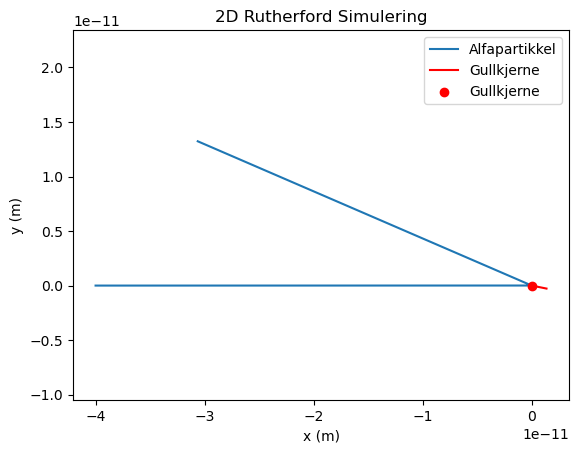

In [13]:
fig, ax = plt.subplots()
ax.plot(r2[:, 0], r2[:, 1], label="Alfapartikkel")
ax.plot(r1[:, 0], r1[:, 1], color="red", label="Gullkjerne")
ax.scatter(0, 0, color="red", zorder=5, label="Gullkjerne")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("2D Rutherford Simulering")
ax.axis("equal")
ax.legend()
plt.savefig("assets/rutherford1.png", dpi=300)
plt.show()

In [7]:
v = dr2[-1]
v0 = dr2[0]
cos_theta = np.dot(v0, v) / (np.linalg.norm(v0) * np.linalg.norm(v))
theta = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
print(f"Avbøyningsvinkel: {theta:.2f}°")

Avbøyningsvinkel: 156.63°
